# Phase 5 - Modelling
scikit-learn only (no pretrained models, no AutoML). Final pipeline in `tools/task1/task1_models.py`.

```
features (Phase 3) --> [1] service model (raw min) --OOF--> pred_svc per stop
                                     |
                     [2] re-simulate each route with pred_svc --> sim_pred_arrival, sim_pred_slack
                                     |
                     [3] arrival-residual model (actual - simulated) --OOF--> pred_slack2
                                     |
                     [4] lateness classifier x5 seeds (features + 1-3) --> pred_late_prob
features --> service: mean(raw-target bag x3, log-target bag x3); Style/Tech rows also averaged with a Style/Tech model --> pred_service_min
```
Out-of-fold (OOF) predictions are grouped by route, so a stacked feature on a training row never comes from a model that saw that row's route.

In [1]:
import sys, json, time; sys.path.append("../../tools/task1")
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from task1_common import *
from task1_validation import FOLDS, service_metrics, late_metrics
import task1_models as tm
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
t = load_task1_tables()

## 1. Experiment log
Run on the three Phase 4 folds (mean over folds) before fixing the pipeline. Differences below ~0.01 MAE / 0.0005 log-loss are within seed noise.

**Service time** (baseline quick GBM on log target: MAE 3.622, RMSE 5.738)

| Experiment | MAE | RMSE | Kept? |
|---|---|---|---|
| Raw-minute target (squared error) | 3.600 | 5.547 | yes |
| Absolute-error loss | 3.671 | 5.998 | no |
| Poisson / gamma loss | 3.601 / 3.600 | 5.610 / 5.664 | no |
| Bigger trees, early stopping | 3.615-3.628 | 5.72-5.77 | no |
| Recency weighting (half-life 90-365 d), 60-day burn-in | 3.61-3.66 | 5.52-5.61 | no - process is stable |
| Level-2 with simulated arrival + OOF late prob | 3.618-3.622 | 5.62-5.63 | no |
| Blend raw + log bags (feature subsample 0.5) | 3.585 | 5.579 | yes |
| + Style/Tech segment model | **3.582** | **5.504** | yes |

**Lateness** (baseline quick GBM: log-loss 0.1393, AUC 0.9780)

| Experiment | log-loss | AUC | Kept? |
|---|---|---|---|
| Recency weighting / burn-in | 0.1391-0.1425 | 0.977-0.978 | no |
| Stack: re-simulate routes with predicted service | 0.1374 | 0.9785 | yes |
| + arrival-residual model -> predicted slack | 0.1372 | 0.9785 | yes |
| Tuned trees (15 leaves, feature subsample 0.5, lr 0.02) | 0.1365 | 0.9789 | yes |
| Bag of 5 seeds | 0.1362 | 0.9790 | yes (stabler calibration) |


## 2. Inputs

In [2]:
FD = PROCESSED / 'folds'
fmeta = json.load(open(FD / 'folds_meta.json')); FEATURES = fmeta['features']
folds = {n: (pd.read_pickle(FD / f'{n}_train.pkl'), pd.read_pickle(FD / f'{n}_valid.pkl')) for n, _, _ in FOLDS}
arrivals = pd.read_pickle(INTERIM / 'train_actuals_diagnostic.pkl')[['delivery_id', 'arrival_time_m']]
def arrival_for(df):
    return df[['delivery_id']].merge(arrivals, on='delivery_id', how='left', validate='one_to_one').arrival_time_m
print({n: (a.shape, b.shape) for n, (a, b) in folds.items()}, '| features', len(FEATURES))

{'A_FebMar25': ((49055, 106), (4851, 106)), 'B_SepOct25': ((71984, 106), (4996, 106)), 'C_recent': ((86721, 106), (5173, 106))} | features 101


## 3. Cross-validate the final pipeline (~5 min)
Also records ablations from the pipeline's parts: single stage-1 service model, raw bag, log bag, and a lateness model *without* stacking.

In [3]:
rows, oof_store = [], {}
for name, (X_tr, X_va) in folds.items():
    t0 = time.time()
    models = tm.fit(X_tr, arrival_for(X_tr), FEATURES, t['traffic'], verbose=False)
    svc, late, parts = tm.predict(models, X_va, t['traffic'], return_parts=True)
    no_stack = HistGradientBoostingClassifier(categorical_features='from_dtype', random_state=SEED, **tm.LATE).fit(X_tr[FEATURES], X_tr.late).predict_proba(X_va[FEATURES])[:, 1]
    y_s, y_l = X_va.service_min.values, X_va.late.values
    for label, p in [('service: stage-1 single model', parts['svc_stage1']), ('service: raw bag', parts['svc_raw']),
                     ('service: log bag', parts['svc_log']), ('service: FINAL', svc)]:
        rows.append({'fold': name, 'model': label, **service_metrics(y_s, p)})
    for label, p in [('late: no stacking', no_stack), ('late: FINAL (stacked)', late)]:
        rows.append({'fold': name, 'model': label, **late_metrics(y_l, p)})
    oof_store[name] = pd.DataFrame({'brand': X_va.brand.astype(str).values, 'district': X_va.district.astype(str).values,
                                    'y_svc': y_s, 'p_svc': svc, 'y_late': y_l, 'p_late': late, 'monsoon': X_va.monsoon.values})
    print(f'{name}: {time.time() - t0:.0f}s')
cv = pd.DataFrame(rows)

A_FebMar25: 87s
B_SepOct25: 126s
C_recent: 151s


In [4]:
svc_cols, late_cols = ['MAE', 'RMSE', 'R2', 'MAE_log'], ['logloss', 'brier', 'AUC', 'ECE', 'mean_pred', 'rate']
print('SERVICE (mean over folds)'); print(cv[cv.model.str.startswith('service')].groupby('model')[svc_cols].mean().round(3).sort_values('MAE'))
print('\nLATENESS (mean over folds)'); print(cv[cv.model.str.startswith('late')].groupby('model')[late_cols].mean().round(4))
print('\nper fold:'); print(cv[cv.model.str.contains('FINAL')].set_index(['model', 'fold'])[['MAE', 'RMSE', 'logloss', 'AUC', 'ECE']].round(4))

SERVICE (mean over folds)
                                 MAE   RMSE     R2  MAE_log
model                                                      
service: FINAL                 3.582  5.504  0.822    0.206
service: stage-1 single model  3.600  5.524  0.821    0.207
service: log bag               3.603  5.719  0.809    0.207
service: raw bag               3.607  5.527  0.821    0.208

LATENESS (mean over folds)
                       logloss   brier     AUC     ECE  mean_pred    rate
model                                                                    
late: FINAL (stacked)   0.1357  0.0425  0.9792  0.0083     0.1641  0.1682
late: no stacking       0.1389  0.0434  0.9781  0.0082     0.1649  0.1682

per fold:
                                     MAE    RMSE  logloss     AUC     ECE
model                 fold                                               
service: FINAL        A_FebMar25  3.5910  5.4382      NaN     NaN     NaN
late: FINAL (stacked) A_FebMar25     NaN     NaN   0.1545

## 4. Against the Phase 4 baselines

In [5]:
bs = pd.read_csv(METRICS / 'task1_baselines_service.csv').groupby('model')[['MAE', 'RMSE']].mean()
bl = pd.read_csv(METRICS / 'task1_baselines_late.csv').groupby('model')[['logloss', 'brier', 'AUC']].mean()
fin_s = cv[cv.model == 'service: FINAL'][['MAE', 'RMSE']].mean().rename('FINAL pipeline')
fin_l = cv[cv.model == 'late: FINAL (stacked)'][['logloss', 'brier', 'AUC']].mean().rename('FINAL pipeline')
print(pd.concat([bs, fin_s.to_frame().T]).round(3)); print(); print(pd.concat([bl, fin_l.to_frame().T]).round(4))
d_s = 1 - fin_s.MAE / bs.loc['S1 allowance', 'MAE']; d_l = 1 - fin_l.logloss / bl.loc['L2 logit(plan slack)', 'logloss']
print(f'\nvs the dispatcher today: service MAE -{d_s:.0%} vs allowance; lateness log-loss -{d_l:.0%} vs planned-slack logistic')

                     MAE    RMSE
S0 brand median    6.660  10.673
S1 allowance       6.608  10.251
S2 outlet history  4.769   7.624
S3 quick GBM       3.622   5.738
FINAL pipeline     3.582   5.504

                      logloss   brier     AUC
L0 base rate           0.4566  0.1410  0.5000
L1 brand x monsoon     0.4338  0.1345  0.5898
L2 logit(plan slack)   0.3184  0.0948  0.8677
L3 logit(sim slack)    0.1883  0.0543  0.9556
L4 quick GBM           0.1393  0.0436  0.9780
FINAL pipeline         0.1357  0.0425  0.9792

vs the dispatcher today: service MAE -46% vs allowance; lateness log-loss -57% vs planned-slack logistic


## 5. Error analysis and calibration

service MAE by brand:
         MAE  mean_actual  mean_pred      n
brand                                      
Fresh   3.22        16.05      15.44  14304
Style    9.8        47.83      48.35    450
Tech   12.33        60.28      57.49    266

lateness by brand / monsoon (observed vs predicted rate):
               observed  predicted     n
brand monsoon                           
Fresh 0           0.128      0.125  9827
      1           0.275      0.267  4477
Style 0           0.030      0.032   304
      1           0.068      0.077   146
Tech  0           0.016      0.016   182
      1           0.036      0.030    84


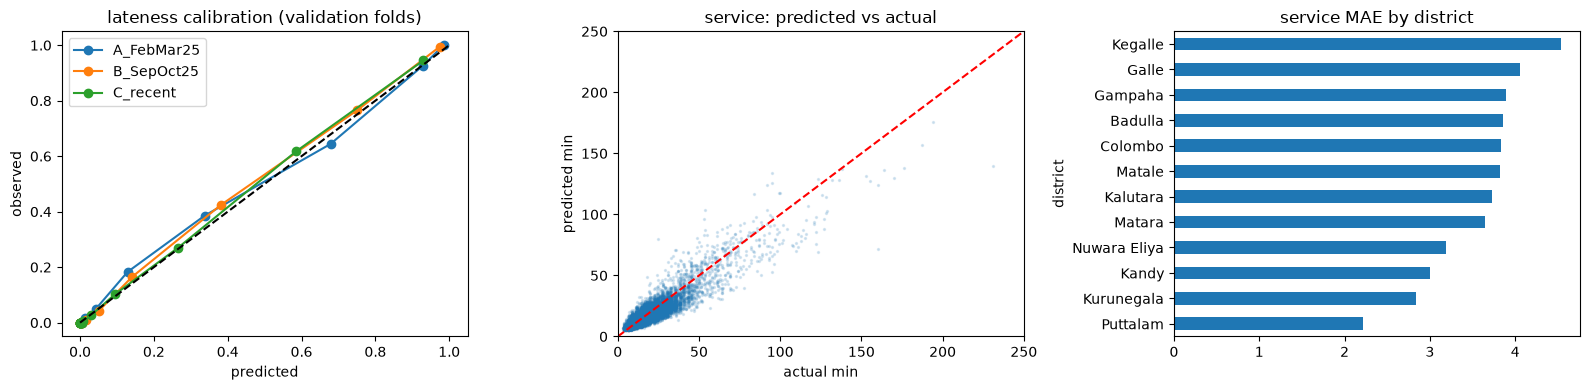

In [6]:
oof = pd.concat(oof_store, names=['fold']).reset_index(level=0)
oof['abs_err'] = (oof.y_svc - oof.p_svc).abs()
print('service MAE by brand:'); print(oof.groupby('brand').agg(MAE=('abs_err', 'mean'), mean_actual=('y_svc', 'mean'), mean_pred=('p_svc', 'mean'), n=('y_svc', 'size')).round(2))
print('\nlateness by brand / monsoon (observed vs predicted rate):')
print(oof.groupby(['brand', 'monsoon']).agg(observed=('y_late', 'mean'), predicted=('p_late', 'mean'), n=('y_late', 'size')).round(3))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for name, g in oof.groupby('fold'):
    b = pd.qcut(g.p_late, 15, duplicates='drop'); c = g.groupby(b, observed=True)[['p_late', 'y_late']].mean()
    ax[0].plot(c.p_late, c.y_late, marker='o', label=name)
ax[0].plot([0, 1], [0, 1], 'k--'); ax[0].set_title('lateness calibration (validation folds)'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('observed'); ax[0].legend()
ax[1].scatter(oof.y_svc, oof.p_svc, s=2, alpha=.15); ax[1].plot([0, 250], [0, 250], 'r--'); ax[1].set_xlim(0, 250); ax[1].set_ylim(0, 250)
ax[1].set_title('service: predicted vs actual'); ax[1].set_xlabel('actual min'); ax[1].set_ylabel('predicted min')
oof.groupby('district').abs_err.mean().sort_values().plot.barh(ax=ax[2]); ax[2].set_title('service MAE by district')
plt.tight_layout(); plt.show()

## 6. What the models use
Permutation importance on fold A (2,000-row sample): service stage-1 model and one lateness classifier (with its stacked inputs).

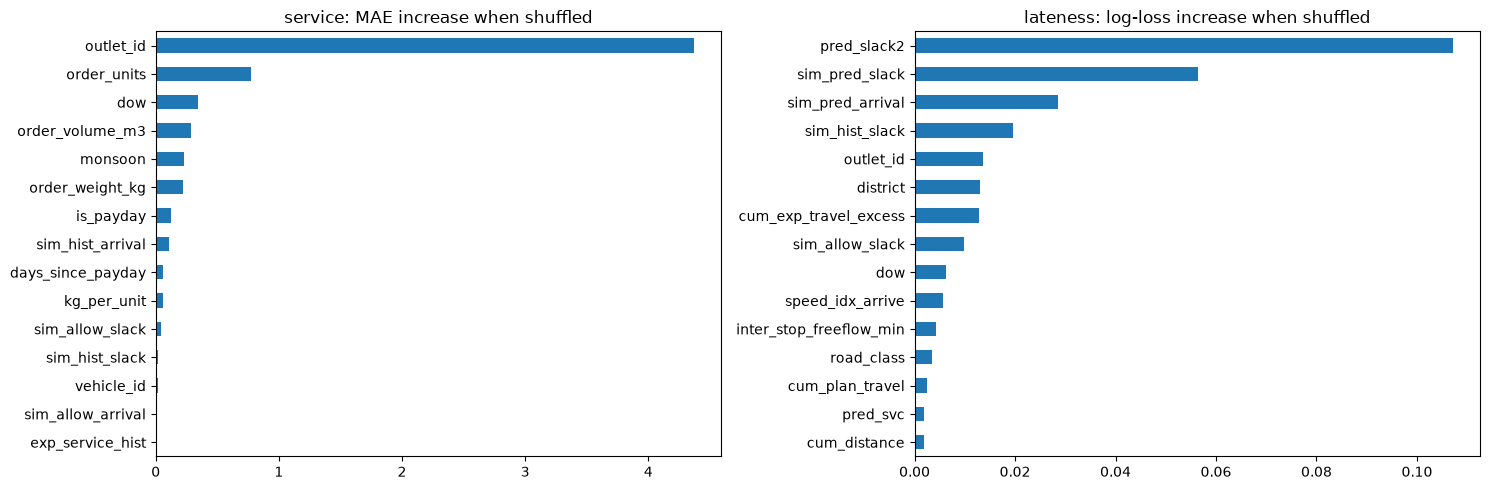

In [7]:
X_tr, X_va = folds['A_FebMar25']
m = tm.fit(X_tr, arrival_for(X_tr), FEATURES, t['traffic'], verbose=False)
s = X_va.sample(2000, random_state=SEED).reset_index(drop=True)
lookup = tm.tf._speed_lookup(t['traffic'])
d = tm._add_stack(s, m['svc_stage1'].predict(s[FEATURES]), lookup)
d['pred_slack2'] = d.sim_pred_slack - m['resid'].predict(d[m['f2']])
pi_s = permutation_importance(m['svc_stage1'], s[FEATURES], s.service_min, scoring='neg_mean_absolute_error', n_repeats=2, random_state=SEED)
pi_l = permutation_importance(m['late'][0], d[m['f3']], d.late, scoring='neg_log_loss', n_repeats=2, random_state=SEED)
imp_s = pd.Series(pi_s.importances_mean, FEATURES).sort_values(ascending=False).head(15)
imp_l = pd.Series(pi_l.importances_mean, m['f3']).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
imp_s[::-1].plot.barh(ax=ax[0]); ax[0].set_title('service: MAE increase when shuffled')
imp_l[::-1].plot.barh(ax=ax[1]); ax[1].set_title('lateness: log-loss increase when shuffled')
plt.tight_layout(); plt.show()

## 7. Fit on all training data and save
Train on the full Phase 3 table (all of 2024-01 to 2026-02-14). Models are saved as a dict of plain scikit-learn estimators.

In [8]:
train_X = pd.read_pickle(PROCESSED / 'task1_train_features.pkl')
meta = json.load(open(PROCESSED / 'task1_feature_meta.json'))
assert meta['features'] == FEATURES
t0 = time.time()
final_models = tm.fit(train_X, arrival_for(train_X), FEATURES, t['traffic'])
print(f'fitted in {time.time() - t0:.0f}s')
MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump(final_models, MODELS / 'task1_models.joblib', compress=3)
cv.to_csv(METRICS / 'task1_cv_final.csv', index=False)
print('saved', MODELS / 'task1_models.joblib', f'({(MODELS / "task1_models.joblib").stat().st_size / 1e6:.1f} MB)')

stage 1: service OOF
stage 3: arrival-residual OOF
stage 4: lateness classifier x5
final service: raw x3, log x3, segment
fitted in 152s
saved C:\Users\Asanka\Desktop\Hackbots_Datathon\HackBots_Datathon_Submision\models\task1_models.joblib (6.5 MB)


### Modelling decisions
| # | Decision | Evidence |
|---|---|---|
| 1 | HistGradientBoosting throughout | Handles NaN and categoricals natively; beat every baseline on every fold |
| 2 | Service: blend raw + log targets + Style/Tech segment model | Best MAE and RMSE (section 1) |
| 3 | Lateness: stacked route re-simulation + arrival-residual model | Consistent log-loss gain on all three folds, largest on the test-like fold A |
| 4 | No recency weighting, use all history | Weighting hurt; the process is stable over time |
| 5 | No post-hoc calibration | Validation ECE is already <0.01 |
